___
### <p style="text-align: right;"> &#9989; Put your name here</p>
___

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />
     
     
# CMSE 201 
## Fall 2021
____


## Homework 5: Modeling Physical Systems and COVID with ODEs 
____


### Goals

#### By the end of this homework, you will:
1. Practice more examples with `solve_ivp` and get comfortable using it on different systems 
2. Simulate a differential equation describing a simple RC circuit
3. Simulate spring motion with two differential equations 
4. Simulate COVID with a simple SIR model, and a modified SIR model, closer to real-word research modeling 
5. Think about how to simulate complicated models by simplifying them and crosschecking

___
### Assignment instructions

Work through this notebook and follow the directions. This HW is slightly more conceptual with larger portions of the code given to you. Be sure to look for the questions.

*This assignment is due at the usual time for your section. Ask your instructor if you are unclear on the due time.*

Upload to D2L as usual. 

___
### Grading

* Part 1: Reviewing solve_ivp with an RC circuit (15 pts)
* Part 2: Modeling a spring (15 pts)
* Part 3: Modeling a COVID pandemic with a modified SIR model (15 pts)

**Total:** 45 points

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# Upgrade from the usual boring style
plt.style.use('fivethirtyeight')

____
____

## Part 1: Reviewing `solve_ivp` with an RC circuit  
____


When you learn to use a new library in Python, it's a good idea to be sure that you are using it correctly.
A common approach to this is to think of an example that is easy;
if you already know the answer, you can be sure that an unexpected result is due to a bug rather than a misunderstanding of the problem.

A capacitor is an electronic device that stores energy in an electric field.
The capacitance, $C$, gives the information on how much energy the capacitor can store.
Our cellphones (among many devices) rely on hundreds of tiny capacitors to function. 
Now let's stop by the physics lab and do some experiments.
When our capacitor is fully charged at $t=0$, it carries charge $Q_0$.
When we connect the capacitor across a resistor with resistance $R$, the charge changes as the function of time:

$$\frac{d Q(t)}{d t} = -RC Q(t)\text{,}$$

which is an ordinary differential equation (ODE).
If you've taken enough calculus, you should already know the analytic solution. 

In the spirit of CMSE hands-on experience, let's use `solve_ivp` to solve this ODE as if we didn't know the answer.

First, take a look at what we know: set up the code to plot our known solution for later comparison. 

##### 1.1 [4 Points] Comment every line of this code.


Text(0.5, 1.0, 'Capacitor Discharging')

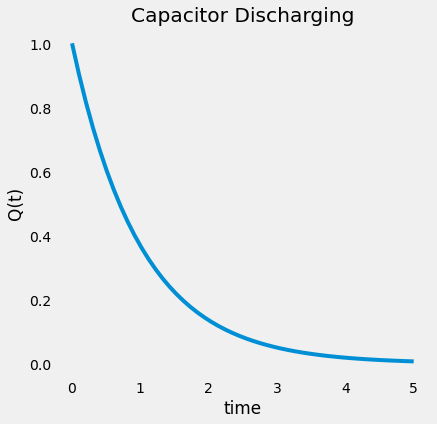

In [4]:
# 
T = 3
# 
time_array = np.linspace(0,5)
# 
Q_0 = 1
Rval=1
Cval=1
#
Qt = Q_0*np.exp(-Rval*Cval*time_array)

#
plt.figure(figsize=(6,6))
#
plt.plot(time_array, Qt)
#
plt.grid(alpha=0.25)
#
plt.xlabel("time")
#
plt.ylabel("Q(t)")
#
plt.title("Capacitor Discharging")


Now, the question is:
Can we get `solve_ivp` to give us the same result?
We will follow these steps:
1. Put our equation(s) in the standard form
2. Define the function `solve_ivp` needs to use
3. Define the time range 
4. Define the initial condition(s)
5. Set up parameters for the model
6. Call `solve_ivp`
7. Unpack the results and make a plot

Note that this problem is simple enough that step 1 is automatically done:
$$\frac{d Q(t)}{d t} = -RC Q(t)$$

#### 1.2 [6 Points] 
Change all of the comments in the following code by replacing each "X" with the correct step from above and explain _why_ this step is needed (use as many lines for the comments as you need).
You do not need to change the code itself.

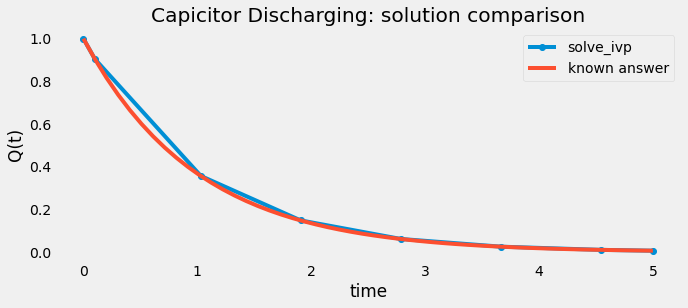

In [8]:
# step X
# this step is needed to.....
#
def capacitor_discharge(time_in, current_value, R_in, C_in): return -R_in*C_in*current_value

# step X
# this step is needed to.....
#
time_range = [0, 5]

# step X
# this step is needed to.....
#
initial_conditions = [Q_0]

# step X
# this step is needed to.....
#
my_parameter = [Rval, Cval]

# step X
# this step is needed to.....
#
my_solution = solve_ivp(capacitor_discharge,  # store the equations of our model
                        time_range,           # when to start and when to end
                        initial_conditions,   # where we want to start from
                        args=(my_parameter))  # parameters for the model

# my_solution = solve_ivp(exp_decay, time_range, initial_conditions, t_eval = time_array, args=(my_parameter))

# step X
# this step is needed to.....
#
plt.figure(figsize=(10,4))
plt.plot(my_solution.t, my_solution.y[0], 'o-', label='solve_ivp')
plt.plot(time_array, Qt, label='known answer')
plt.grid(alpha=0.1)
plt.xlabel("time")
plt.ylabel("Q(t)")
plt.title("Capicitor Discharging: solution comparison")
plt.legend()

##### 1.3 [5 Points] How can you improve the agreement between the two solutions given above? 
Show your reasoning, code, and results below. 

In [ ]:
# put your code here and run it 



____
____

## Part 2: Modeling a spring 

Great work so far! Let's ramp this up a bit. 

In this exercise, we are going to simulate how spring moves.
You can see a simple simulation here:
https://www.myphysicslab.com/springs/single-spring-en.html

We will need to keep track of two variables: the position of the block, $x(t)$, and its velocity, $v(t)$.
The change of the position $x$ is related to the velocity via 

$$\frac{d x(t)}{dt} = v(t)$$

The change of the velocity is proportional to the spring force 
$$\frac{d v(t)}{dt} = -k x(t)$$
where $k$ is the spring constant (telling us how stiff the spring is).

To describe the position and velocity of the spring, we will follow these steps:
1. Put our equation(s) in the standard form (3 points)
2. Define the function `solve_ivp` needs to use (2 points)
3. Define the time range 
4. Define the initial condition(s) 
5. Set up parameters for the model
6. Call `solve_ivp` (4 points)
7. Unpack the results and make a plot (4 points)

In the cells below, fill in the missing code you need for the simulation.

In [17]:
# Step 1: Put our equation(s) in the standard form  (4 points)
# Your code below:

In [ ]:
# Step 2: Define the function solve_ivp needs to use (2 points)
# Your code below:

In [ ]:
# Step 3: Define the time range 
tend=100
time_array = np.linspace(0, tend, 1000) 
time_range = [0,tend]

In [ ]:
# Step 4: Define the initial condition(s) 
first_initial_conditions = [0.2, 0.2] 

In [ ]:
# Step 5: Set up parameters for the model
k = 0.1 

In [ ]:
# Step 6: Call `solve_ivp` (4 points)
# Your code below:

In [ ]:
# Step 7: Unpack the results and make a plot (4 points)
# Your code below:

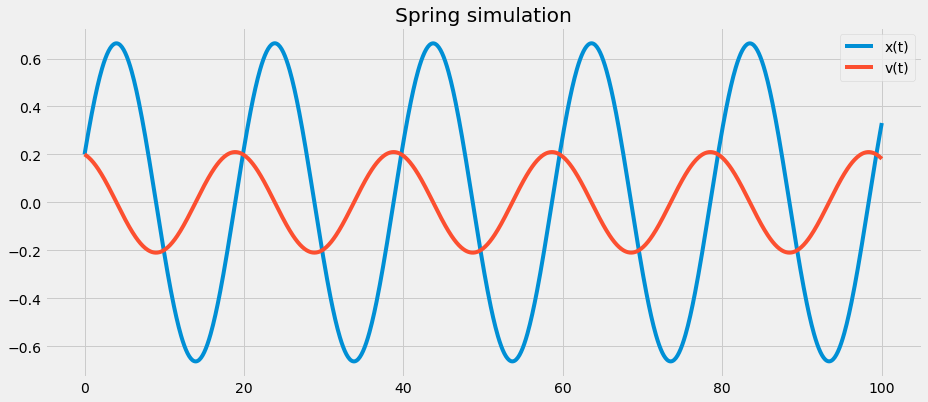

In [10]:
#Answer 

def spring_simulation(t, y, k):
    # unpack incoming solution into its pieces; give meaningful names
    x = y[0]
    v = y[1]
    # return the current derivatives back to solve_ivp
    return v, -k*x


# set up what solve_ivp is going to need
initial_conditions = [0.2, 0.2] 
k = 0.1 # spring constant

tend=100
time_array = np.linspace(0, tend, 1000) # s
time_range = [0,tend]

solution = solve_ivp(spring_simulation,   # function to use with derivatives
                     time_range,          # time period over which we want a solution
                     initial_conditions,  # where we want the variables to start
                     t_eval=time_array,   # get a lot of points so that the plots look good
                     args=[k])            # pass parameters the model needs beyond the variables


plt.figure(figsize=(14,6))
plt.plot(time_array, solution.y[0], label='x(t)')
plt.plot(time_array, solution.y[1], label='v(t)')
plt.title("Spring simulation")
plt.legend()

**Question:** What happens if you change the spring constant by a factor of 5? (2 points)

____
____

## Part 3: Modeling a COVID pandemic with a modified SIR model
____


A differential-equations model-fitting analysis of COVID-19 epidemiological data is able to explain multi-wave dynamics.
Research along these lines was published in *Nature* using a complicated model.
(See Fig. 1 in https://www.nature.com/articles/s41598-021-95494-6.)

There are too many equations in this model for the homework, so we are going to simplify 
by only considering a modified SIR model.

 - $S$: susceptible population 
 - $I$: infected population spreading the virus 
 - $R$: total recovered
 - $P$: protected population 

$$\frac{dS(t)}{dt} = k_{PS} P(t) - \beta S(t) I(t),$$
$$\frac{dI(t)}{dt} = \beta S(t)I(t) - \gamma I(t),$$
$$\frac{dR(t)}{dt} = \gamma I(t) + v - k_{RP} R $$
$$\frac{dP(t)}{dt} = k_{RP} R(t) -k_{PS} P(t) -v,$$

where 
- $k_{RP}$: characteristic reinfection rate 
- $k_{PS}$: transition rate from protected back to susceptible
- $v$: daily vaccinated
$\beta$ and $\gamma$ are the same as what we used in the in-class exercise:
- $\beta$: infectivity rate
- $\gamma$: recovery rate

For this part of the exercises, we will start with a 3-equation SIR model, and you will expand the code to the modified model. 
This is important: always start with something that we are familiar with or a simplified version of the model before trying something harder. 

### 3.1 : Start with SIR model
____


Let's start with the basic SIR model, since you are already familiar with that. It has the ODE form
$$\frac{dS(t)}{dt} = -\beta S(t) I(t),$$
$$\frac{dI(t)}{dt} = \beta S(t) I(t) - \gamma I(t),$$
$$\frac{dR(t)}{dt} = \gamma I(t).$$

Your task is to code this model using `solve_ivp`. Note that this is a little different from what you have done earlier in this assignment. 

##### Task: [5 points] Complete the code 

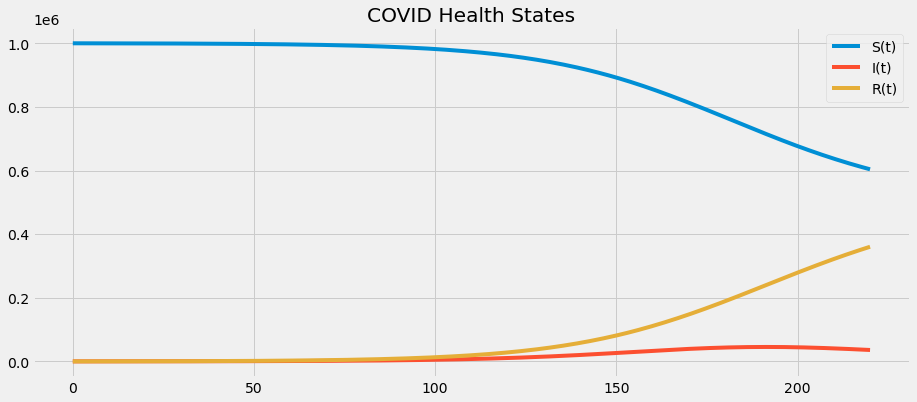

In [31]:
###############
# SIR Model 
###############
# SIR function 
def sir_fun(t, y, beta, gamma):
    # unpack incoming solution into its pieces; give meaningful names
    S = y[0]
    I = y[1]
    R = 
    # return the current derivatives back to solve_ivp
    return -beta*S*I, beta*S*I - gamma*I, 


# set up what solve_ivp is going to need
initial_conditions = [1e6, 100, 0] # this is for a region with about a million people
tend = 220 # number of days to run (you will be varying this)
time_span = [0, ] 
beta = 1.4e-7
gamma = 1/10 # people recover in about 10 days
time_array = np.linspace(0, , 500) # get more points


first_solution = solve_ivp(,       # function to use with derivatives
                           ,       # time period over which we want a solution
                           ,       # where we want the variables to start
                           ,       # get a lot of points so that the plots look good
                           args=   # pass parameters the model needs beyond the variables


plt.figure(figsize=(14,6))
plt.plot(time_array_plotting, first_solution.y[0], label='S(t)')
plt.plot(time_array_plotting, first_solution.y[1], label='I(t)')
plt.plot(time_array_plotting, first_solution.y[2], label='R(t)')
plt.title("Simplifed SIR Model")
# add legends and labels 



### 3.2 : Expand to modified SIR model 

##### task (10 points)
Now copy-paste the working code above, and make changes according to the formula given in the beginning of Part 3.
Complete the following code, and write down your observations on how this changes the simulation results.

In [ ]:
###############
# Modified SIR Model 
###############
# Modified SIR function 
def modified_sir_fun(t, y, ....
    # unpack incoming solution into its pieces; give meaningful names
    S = y[0]
    I = y[1]
    R = 
    P =                
    # return the current derivatives back to solve_ivp
    return                 
            
                     
# set up what solve_ivp is going to need
initial_conditions = [1e6, 100, 0, 1e4] # this is for a region with about a million people
tend = 220 # number of days to run (you will be varying this)
time_span = [0, ] 
beta = 1.4e-7
gamma = 1/10 # people recover in about 10 days
kRP=0.01
kPS=0.01
v=1000
                     
        
time_array = np.linspace(0, , 500) # get more points
                     
                     
second_solution = solve_ivp(,     # function to use with derivatives
                           ,      # time period over which we want a solution
                           ,      # where we want the variables to start
                           ,      # get a lot of points so that the plots look good
                           args=  # pass parameters the model needs beyond the variables

# add plotting code below 
                            

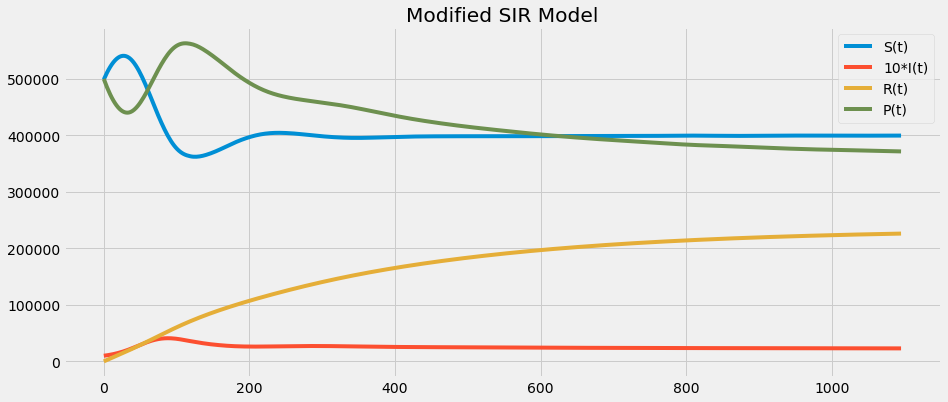

In [74]:
## ANSWER

###############
# Modified SIR Model 
###############
# Modified SIR function 
def modified_sir_fun(t, y, beta, gamma, kPS, kRP, v):
    # unpack incoming solution into its pieces; give meaningful names
    S = y[0]
    I = y[1]
    R = y[2]
    P = y[3]              
    # return the current derivatives back to solve_ivp
    return -kSPI*S*I + kPS*P + kRS*R - beta*S*I, \
           beta*S*I - gamma*I, \
           gamma*I + v - kRS*R, \
           kSPI*S*I - kPS*P - v
            

# set up what solve_ivp is going to need
initial_conditions = [1e6-5e5-1e3, 1e3, 0, 5e5] # this is for a region with about a million people
pop = sum(initial_conditions)
tend = 3*365 # number of days to run
time_span = [0,tend] 
beta = 1/6/pop
gamma = 1/15
kRS=1/360
kPS=1/90
kSPI=5/pop
v=500
                     
time_array = np.linspace(0, tend, 500) # get more points
                     
                     
second_solution = solve_ivp(modified_sir_fun,      # function to use with derivatives
                           time_span,              # time period over which we want a solution
                           initial_conditions,     # where we want the variables to start
                           t_eval = time_array ,   # get a lot of points so that the plots look good
                           args=(beta, gamma, kPS, kRP, v))  # pass parameters the model needs beyond the variables

# add plotting code below 

plt.figure(figsize=(14,6))
plt.plot(time_array, second_solution.y[0], label='S(t)')
plt.plot(time_array, 10*second_solution.y[1], label='10*I(t)')
plt.plot(time_array, second_solution.y[2], label='R(t)')
plt.plot(time_array, second_solution.y[3], label='P(t)')
plt.title("Modified SIR Model")
plt.legend()


Under what conditions will this modified model reproduce the original SIR model?
Can you verify that?

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  
Go to the "Homework Assignments" section, find the appropriate submission folder link, and upload it there.


&#169; Copyright 2021, [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.